In [45]:
import pulp
import matplotlib.pyplot as plt


In [46]:
warehouses = ['Mumbai_WH', 'Delhi_WH', 'Bangalore_WH', 'Hyderabad_WH']

cities = [
    'Pune', 'Ahmedabad', 'Jaipur', 'Chennai',
    'Kolkata', 'Lucknow', 'Nagpur', 'Indore'
]


In [47]:
opening_cost = {
    'Mumbai_WH': 9000,
    'Delhi_WH': 8000,
    'Bangalore_WH': 8500,
    'Hyderabad_WH': 7000
}


In [48]:
demand = {
    'Pune': 70,
    'Ahmedabad': 65,
    'Jaipur': 60,
    'Chennai': 75,
    'Kolkata': 80,
    'Lucknow': 55,
    'Nagpur': 50,
    'Indore': 45
}


In [49]:
capacity = {
    'Mumbai_WH': 200,
    'Delhi_WH': 300,
    'Bangalore_WH': 300,
    'Hyderabad_WH': 300
}


In [50]:
shipping_cost = {

('Mumbai_WH','Pune'):3,
('Mumbai_WH','Ahmedabad'):4,
('Mumbai_WH','Jaipur'):6,
('Mumbai_WH','Chennai'):7,
('Mumbai_WH','Kolkata'):8,
('Mumbai_WH','Lucknow'):6,
('Mumbai_WH','Nagpur'):5,
('Mumbai_WH','Indore'):4,

('Delhi_WH','Pune'):7,
('Delhi_WH','Ahmedabad'):6,
('Delhi_WH','Jaipur'):3,
('Delhi_WH','Chennai'):8,
('Delhi_WH','Kolkata'):7,
('Delhi_WH','Lucknow'):4,
('Delhi_WH','Nagpur'):6,
('Delhi_WH','Indore'):5,

('Bangalore_WH','Pune'):6,
('Bangalore_WH','Ahmedabad'):7,
('Bangalore_WH','Jaipur'):8,
('Bangalore_WH','Chennai'):3,
('Bangalore_WH','Kolkata'):6,
('Bangalore_WH','Lucknow'):7,
('Bangalore_WH','Nagpur'):5,
('Bangalore_WH','Indore'):6,

('Hyderabad_WH','Pune'):5,
('Hyderabad_WH','Ahmedabad'):6,
('Hyderabad_WH','Jaipur'):7,
('Hyderabad_WH','Chennai'):4,
('Hyderabad_WH','Kolkata'):5,
('Hyderabad_WH','Lucknow'):6,
('Hyderabad_WH','Nagpur'):3,
('Hyderabad_WH','Indore'):4

}


In [51]:
model = pulp.LpProblem("Advanced_Warehouse_Optimization", pulp.LpMinimize)


In [52]:
open_wh = pulp.LpVariable.dicts("Open", warehouses, cat="Binary")

ship = pulp.LpVariable.dicts(
    "Ship",
    [(w,c) for w in warehouses for c in cities],
    lowBound=0
)


In [53]:
model += (
    pulp.lpSum(opening_cost[w]*open_wh[w] for w in warehouses) +
    pulp.lpSum(shipping_cost.get((w,c),0) * ship[(w,c)] for w in warehouses for c in cities)
)


In [54]:
for c in cities:
    model += pulp.lpSum(ship[(w,c)] for w in warehouses) == demand[c]


In [55]:
for w in warehouses:
    model += pulp.lpSum(ship[(w,c)] for c in cities) <= capacity[w] * open_wh[w]


In [56]:
budget = 40000

model += pulp.lpSum(opening_cost[w] * open_wh[w] for w in warehouses) <= budget


In [57]:
print("Total Demand:", sum(demand.values()))
print("Total Capacity:", sum(capacity.values()))


Total Demand: 500
Total Capacity: 1100


In [58]:
model.solve()


1

In [59]:
print("Status:", pulp.LpStatus[model.status])

print("\nOpened Warehouses:")
for w in warehouses:
    if open_wh[w].value() == 1:
        print(w)

print("\nShipping Plan:")

for w in warehouses:
    for c in cities:
        if ship[(w,c)].value() > 0:
            print(w,"→",c,"=",ship[(w,c)].value())

print("\nTotal Cost =", pulp.value(model.objective))


Status: Optimal

Opened Warehouses:
Delhi_WH
Hyderabad_WH

Shipping Plan:
Delhi_WH → Ahmedabad = 65.0
Delhi_WH → Jaipur = 60.0
Delhi_WH → Lucknow = 55.0
Delhi_WH → Indore = 20.0
Hyderabad_WH → Pune = 70.0
Hyderabad_WH → Chennai = 75.0
Hyderabad_WH → Kolkata = 80.0
Hyderabad_WH → Nagpur = 50.0
Hyderabad_WH → Indore = 25.0

Total Cost = 17190.0


In [60]:
warehouse_cost = sum(opening_cost[w] * open_wh[w].value() for w in warehouses)

shipping_cost_total = sum(
    shipping_cost.get((w,c),0) * ship[(w,c)].value()
    for w in warehouses for c in cities
)

print("\nWarehouse Opening Cost:", warehouse_cost)
print("Shipping Cost:", shipping_cost_total)



Warehouse Opening Cost: 15000.0
Shipping Cost: 2190.0


In [61]:
import pandas as pd

shipment_data = []

for w in warehouses:
    for c in cities:
        val = ship[(w,c)].value()
        if val and val > 0:
            shipment_data.append([w, c, val])

shipment_df = pd.DataFrame(
    shipment_data,
    columns=["Warehouse", "City", "Units Shipped"]
)

print("\nShipment Table")
print(shipment_df)




Shipment Table
      Warehouse       City  Units Shipped
0      Delhi_WH  Ahmedabad           65.0
1      Delhi_WH     Jaipur           60.0
2      Delhi_WH    Lucknow           55.0
3      Delhi_WH     Indore           20.0
4  Hyderabad_WH       Pune           70.0
5  Hyderabad_WH    Chennai           75.0
6  Hyderabad_WH    Kolkata           80.0
7  Hyderabad_WH     Nagpur           50.0
8  Hyderabad_WH     Indore           25.0


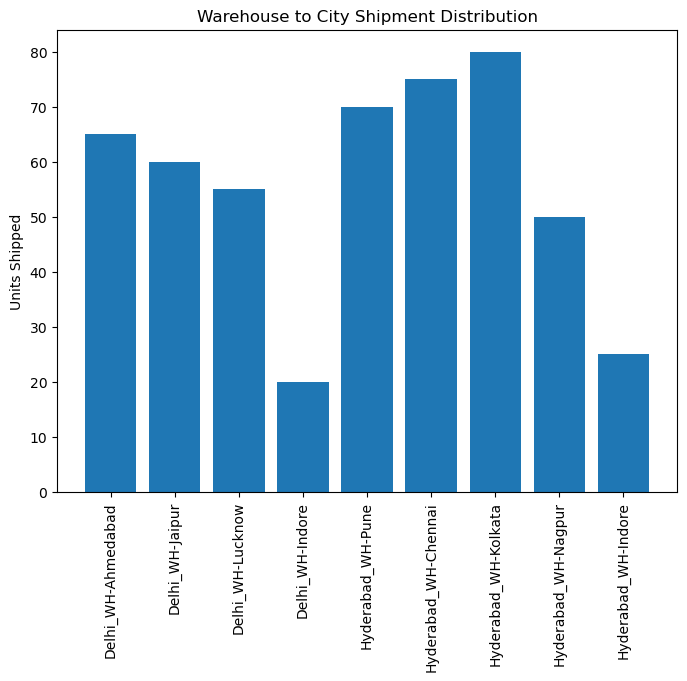

In [64]:
labels = []
values = []

for w in warehouses:
    for c in cities:
        if ship[(w,c)].value() > 0:
            labels.append(f"{w}-{c}")
            values.append(ship[(w,c)].value())

plt.figure(figsize=(8,6))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.title("Warehouse to City Shipment Distribution")
plt.ylabel("Units Shipped")
plt.show()
